In [2]:
import pandas as pd
URL = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
df = pd.read_csv(URL)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

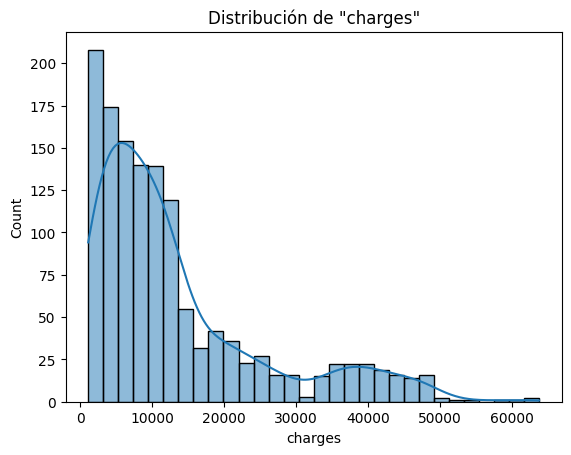

In [12]:
#Distribución de "charges"
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['charges'], kde = True)
plt.title('Distribución de "charges"')
plt.show()

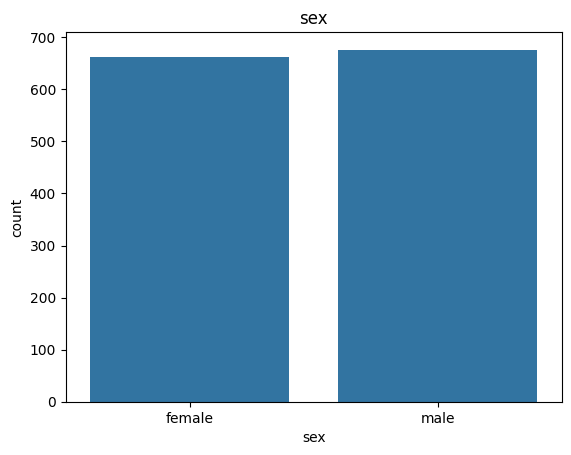

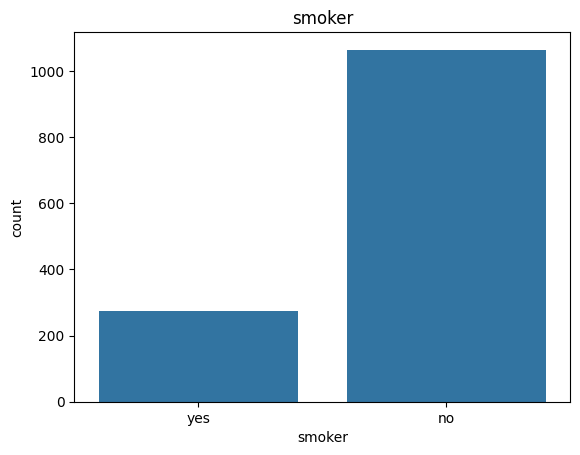

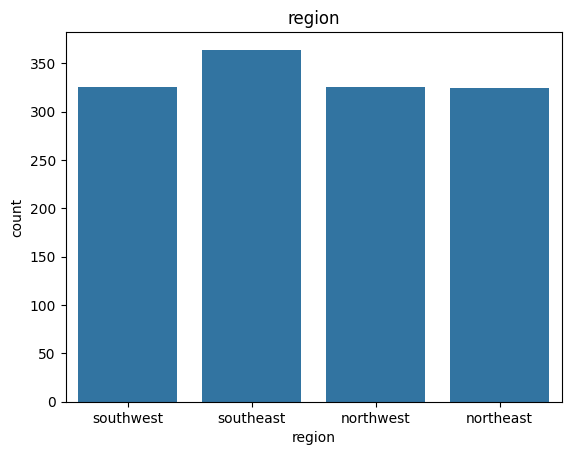

In [15]:
#Variables numéricas
num_cols = ['age','bmi','children','charges']
df[num_cols].hist
plt.show()

#Variales categóricas
cat_cols = ['sex','smoker','region']
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

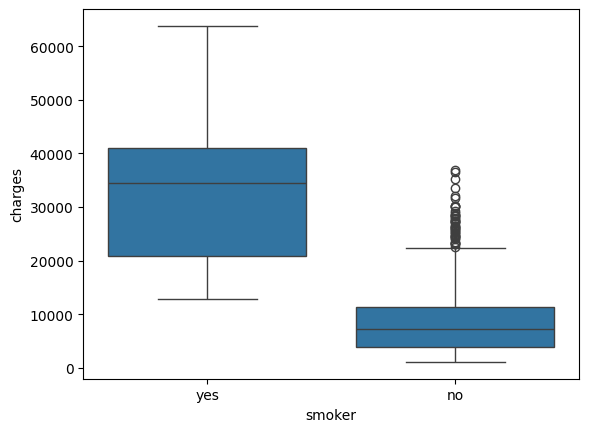

In [16]:
#¿Smoker influye en más en charges?
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

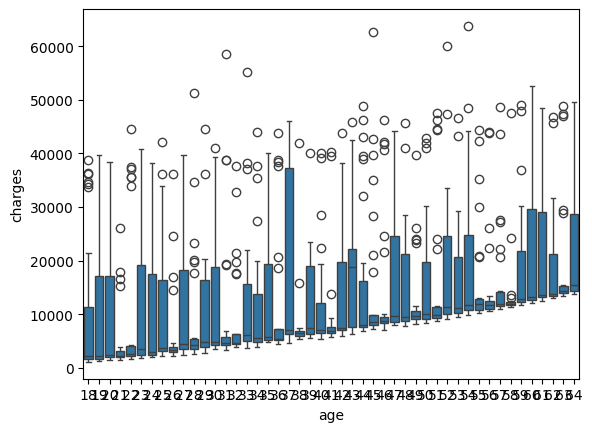

In [17]:
#¿Age influye en más en charges?
sns.boxplot(x='age', y='charges', data=df)
plt.show()

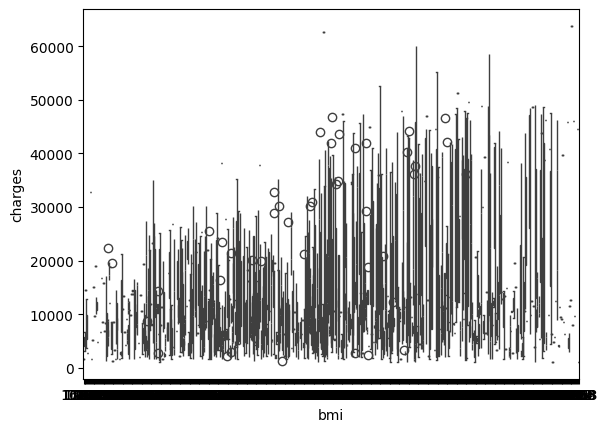

In [18]:
#¿BMI influye en más en charges?
sns.boxplot(x='bmi', y='charges', data=df)
plt.show()

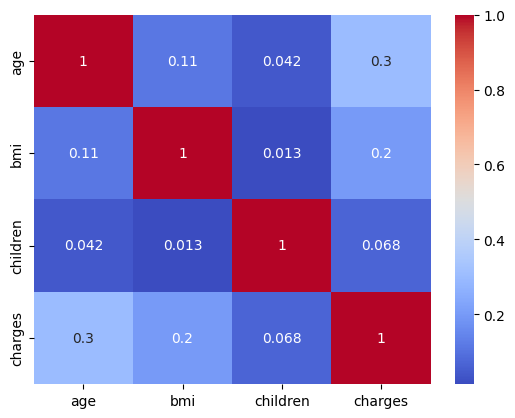

In [20]:
#Correlación
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [26]:
df = pd.get_dummies(df, drop_first=True)

x = df.drop('charges', axis = 1)
y = df['charges'] 


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [30]:
#Regresión linear
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print ('MAE:',mae)
print ('RMSE:',rmse)
print ('R2:',r2)


MAE: 4181.19447375365
RMSE: 5796.284659276273
R2: 0.7835929767120724


In [36]:
#Optimización
import numpy as np
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)
model.fit(x_train, y_train_log)
y_pred_log = model.predict(x_test)
y_pred = np.exp(y_pred_log)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_train_scaled)

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print ('R2 RF',r2_score(y_test, y_pred_rf))

R2 RF 0.8633308963267636


In [ ]:
#La variable que más influye es "smoker"
#La multicolinealidad es baja
#La regresión lineal funciona bien, ya que R2 va entre 0.7 - 0.8 